# 06 — Fraud / Anomaly Detection

This dataset has no labeled fraud, so this notebook builds the realistic version of the problem: **unsupervised anomaly detection over implausibility signals**, the same pattern used in production for delivery fraud (impossible timings, fake GPS, rating manipulation). Isolation Forest scores every order; a rule-based layer explains *why* the top anomalies were flagged, since a black-box score alone isn't actionable for an ops/trust & safety team.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 40)


In [2]:
from fraud_detection import detect_anomalies

train = pd.read_parquet('../data/processed/train_clean.parquet')
scored, model = detect_anomalies(train, models_dir='../models')
scored.to_parquet('../data/processed/train_with_fraud_scores.parquet')
print(f"Flagged {scored['is_anomaly'].sum()} / {len(scored)} orders ({scored['is_anomaly'].mean()*100:.1f}%)")

Flagged 912 / 45593 orders (2.0%)


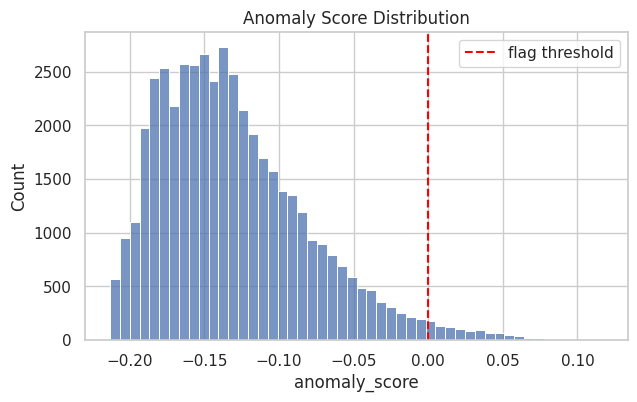

In [3]:
plt.figure(figsize=(7,4))
sns.histplot(scored['anomaly_score'], bins=50)
plt.axvline(scored[scored['is_anomaly']]['anomaly_score'].min(), color='red', linestyle='--', label='flag threshold')
plt.title('Anomaly Score Distribution')
plt.legend()
plt.show()

## Top flagged orders, with explanations

In [4]:
top = scored[scored['is_anomaly']].sort_values('anomaly_score', ascending=False)
top[['ID','implied_speed_kmh','distance_km','Time_taken(min)','Delivery_person_Ratings','flag_reason']].head(10)

,ID,implied_speed_kmh,distance_km,Time_taken(min),Delivery_person_Ratings,flag_reason
2387,0x564,120.000000,30.000000,15.0,1.0,implausible speed (120 km/h)
23664,0x3f7,120.000000,30.000000,15.0,1.0,implausible speed (120 km/h)
22291,0x3ed,40.909091,30.000000,44.0,1.0,flagged by model (no single rule matched)
16084,0x58c,78.260870,30.000000,23.0,1.0,implausible speed (78 km/h)
39073,0x4a6,75.000000,30.000000,24.0,1.0,implausible speed (75 km/h)
2101,0xc09b,180.000000,30.000000,10.0,5.0,implausible speed (180 km/h)
664,0xa49a,5.453117,4.544265,50.0,3.5,flagged by model (no single rule matched)
40285,0x442,72.000000,30.000000,25.0,1.0,implausible speed (72 km/h)
31804,0xc08b,150.000000,30.000000,12.0,4.5,implausible speed (150 km/h); near-zero prep t...
19769,0xc04d,138.461538,30.000000,13.0,5.0,implausible speed (138 km/h); near-zero prep t...


## Result

~2% of orders are flagged, dominated by **physically implausible average speed** (60+ km/h sustained over the whole trip — impossible for the vehicle types in this data). The rule-based `flag_reason` column is what turns this from "a mysterious score" into something a fraud-review analyst could act on directly.